# Lab 2 · Conv1D 임베딩 차원(emb_dim) 최적화

Lab3에서 만든 Conv1D 모델을 그대로 가져와서, **임베딩 차원(`emb_dim`)만 바꿔가며** 어떤 값이
가장 좋은 성능을 내는지 찾습니다.

- 실험할 값: `32, 64, 128, 256, 512, 1024`
- 나머지 설정(필터 수, 커널 크기, 학습 조건)은 전부 고정하고 `emb_dim`만 바꿉니다.
- 정확도뿐 아니라 **학습 곡선**도 같이 보면서, 차원이 커질수록 과적합이 더 심해지는지 확인합니다.

In [1]:
!pip install -q koreanize-matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 1. 저장된 파일 불러오기

In [2]:
import urllib.request

url = "https://raw.githubusercontent.com/hongsukyi/DL4NLP/main/notebooks/data.npz"
urllib.request.urlretrieve(url, "data.npz")

('data.npz', <http.client.HTTPMessage at 0x1f13ce7db90>)

In [3]:
data = np.load("data.npz", allow_pickle=True)

ids = data["input_ids"]
y   = data["labels"]

idx_tr  = data["train_idx"]
idx_val = data["val_idx"]
idx_te  = data["test_idx"]

vocab_size = int(data["vocab_size"])
max_len    = int(data["max_len"])
n_cls      = int(data["num_classes"])
pad_id     = int(data["pad_id"])
classes    = data["class_names"].tolist()

X_tr,  y_tr  = ids[idx_tr],  y[idx_tr]
X_val, y_val = ids[idx_val], y[idx_val]
X_te,  y_te  = ids[idx_te],  y[idx_te]

print("train/val/test:", len(X_tr), len(X_val), len(X_te))
print("classes:", classes)

assert pad_id == 0, f"pad_id가 0이 아닙니다({pad_id}). mask_zero=True를 그대로 쓰면 안 됩니다."
print("pad_id:", pad_id, "-> mask_zero=True 사용 가능")

train/val/test: 1680 360 360
classes: ['면접', '학교', '협상']
pad_id: 0 -> mask_zero=True 사용 가능


## 2. Conv1D 모델 정의 (emb_dim을 인자로 받도록)

Lab3와 똑같은 구조이지만, 이번엔 `emb_dim`을 함수 인자로 받아서 여러 값을 실험할 수 있게 합니다.

In [4]:
conv_filters = 64
conv_kernel  = 3

def build_conv1d(emb_dim):
    inp = keras.Input((max_len,))
    x = layers.Embedding(vocab_size, emb_dim, mask_zero=True)(inp)
    x = layers.Conv1D(conv_filters, kernel_size=conv_kernel, padding="same", activation="relu")(x)
    x = layers.SpatialDropout1D(0.3)(x)   # 과적합 방지

    # Conv1D는 mask를 지원하지 않으므로, PAD 위치를 직접 아주 작은 값으로 밀어냅니다.
    is_pad = keras.ops.cast(keras.ops.equal(inp, 0), "float32")
    bias = is_pad[..., None] * -1e9
    x = x + bias

    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    feat = layers.Dense(16, activation="relu", name="feat")(x)
    out = layers.Dense(n_cls, activation="softmax")(feat)
    return keras.Model(inp, out)

def fit_model(model):
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    return model.fit(
        X_tr, y_tr, validation_data=(X_val, y_val),
        batch_size=32, epochs=30, callbacks=[es], verbose=0,
    )

## 3. emb_dim을 바꿔가며 반복 실험

`32, 64, 128, 256, 512, 1024` 여섯 가지 값으로 각각 모델을 새로 만들고 학습시킵니다.

In [5]:
emb_dims = [32, 64, 128, 192, 256]
results = {}   # emb_dim -> {history, test_acc, params}

for dim in emb_dims:
    print(f"=== emb_dim={dim} 학습 중 ===")
    model = build_conv1d(dim)
    h = fit_model(model)

    pred = model.predict(X_te, verbose=0).argmax(axis=1)
    acc = (pred == y_te).mean()

    results[dim] = {
        "val_loss": h.history["val_loss"],
        "val_acc": h.history["val_accuracy"],
        "test_acc": float(acc),
        "n_params": model.count_params(),
        "model": model,   # 마지막에 최적 모델 다시 쓰려고 보관
    }
    print(f"emb_dim={dim:5d}  test_acc={acc:.3f}  params={model.count_params():,}\n")

=== emb_dim=32 학습 중 ===


C:\Users\hongs\anaconda3\envs\qml44\Lib\site-packages\keras\src\layers\layer.py:1039: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


emb_dim=   32  test_acc=0.786  params=1,035,459

=== emb_dim=64 학습 중 ===


C:\Users\hongs\anaconda3\envs\qml44\Lib\site-packages\keras\src\layers\layer.py:1039: UserWarning: Layer 'conv1d_1' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


emb_dim=   64  test_acc=0.850  params=2,065,603

=== emb_dim=128 학습 중 ===


...

emb_dim=  128  test_acc=0.844  params=4,125,891

=== emb_dim=192 학습 중 ===


C:\Users\hongs\anaconda3\envs\qml44\Lib\site-packages\keras\src\layers\layer.py:1039: UserWarning: Layer 'conv1d_3' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


emb_dim=  192  test_acc=0.822  params=6,186,179

=== emb_dim=256 학습 중 ===


C:\Users\hongs\anaconda3\envs\qml44\Lib\site-packages\keras\src\layers\layer.py:1039: UserWarning: Layer 'conv1d_4' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


emb_dim=  256  test_acc=0.853  params=8,246,467



## 4. emb_dim별 정확도 비교

In [6]:
table = pd.DataFrame({
    "emb_dim": emb_dims,
    "Test Accuracy": [results[d]["test_acc"] for d in emb_dims],
    "파라미터 수": [results[d]["n_params"] for d in emb_dims],
}).set_index("emb_dim")

print(table)

         Test Accuracy   파라미터 수
emb_dim                        
32            0.786111  1035459
64            0.850000  2065603
128           0.844444  4125891
192           0.822222  6186179
256           0.852778  8246467


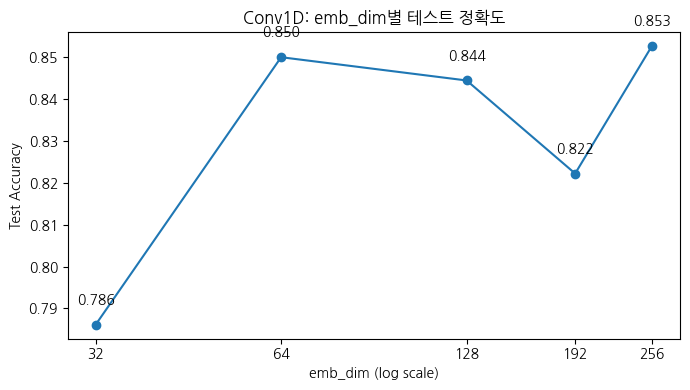

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(table.index, table["Test Accuracy"], marker="o")
plt.xscale("log", base=2)
plt.xticks(emb_dims, emb_dims)
plt.xlabel("emb_dim (log scale)")
plt.ylabel("Test Accuracy")
plt.title("Conv1D: emb_dim별 테스트 정확도")
for d in emb_dims:
    plt.text(d, table.loc[d, "Test Accuracy"] + 0.005, f'{table.loc[d, "Test Accuracy"]:.3f}', ha="center")
plt.tight_layout()
plt.show()

## 5. emb_dim별 학습 곡선 (val_loss) — 과적합 경향 확인

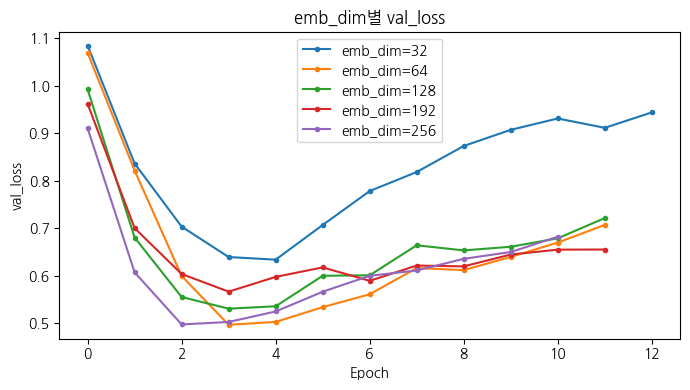

In [8]:
plt.figure(figsize=(7, 4))
for d in emb_dims:
    plt.plot(results[d]["val_loss"], marker="o", markersize=3, label=f"emb_dim={d}")
plt.title("emb_dim별 val_loss")
plt.xlabel("Epoch"); plt.ylabel("val_loss")
plt.legend()
plt.tight_layout()
plt.show()

## 6. 최적 emb_dim 확인 및 상세 결과

In [9]:
best_dim = table["Test Accuracy"].idxmax()
print(f"가장 정확도가 높은 emb_dim: {best_dim} (Test Accuracy={table.loc[best_dim, 'Test Accuracy']:.3f})")

가장 정확도가 높은 emb_dim: 256 (Test Accuracy=0.853)


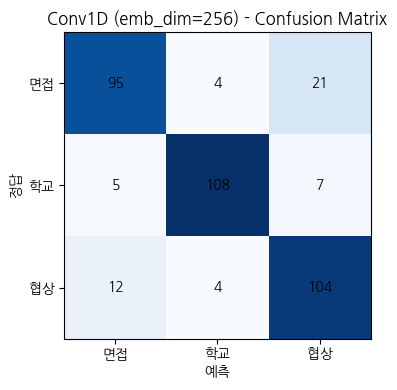

In [10]:
best_model = results[best_dim]["model"]

pred = best_model.predict(X_te, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_te, pred)

plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(n_cls), classes); plt.yticks(range(n_cls), classes)
for i in range(n_cls):
    for j in range(n_cls):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.title(f"Conv1D (emb_dim={best_dim}) - Confusion Matrix")
plt.xlabel("예측"); plt.ylabel("정답")
plt.tight_layout()
plt.show()

C:\Users\hongs\anaconda3\envs\qml44\Lib\site-packages\keras\src\layers\layer.py:1039: UserWarning: Layer 'conv1d_4' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


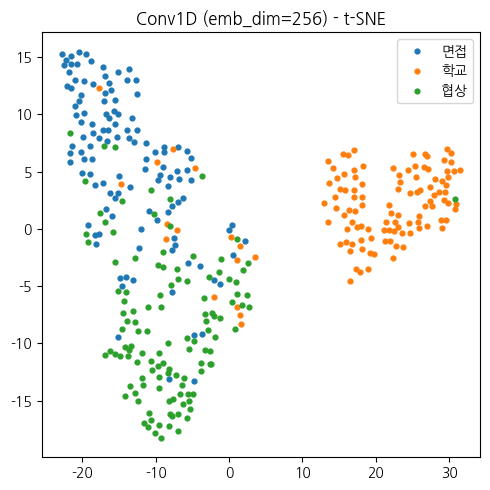

In [11]:
feat_model = keras.Model(best_model.input, best_model.get_layer("feat").output)
feat = feat_model.predict(X_te, verbose=0)
xy = TSNE(n_components=2, random_state=SEED, init="pca", perplexity=30, n_jobs=1).fit_transform(feat)

plt.figure(figsize=(5, 5))
for c_ in range(n_cls):
    m = y_te == c_
    plt.scatter(xy[m, 0], xy[m, 1], s=12, label=classes[c_])
plt.title(f"Conv1D (emb_dim={best_dim}) - t-SNE")
plt.legend()
plt.tight_layout()
plt.show()

## 정리

- `emb_dim`을 32~1024까지 늘려가며 Conv1D 하나로 실험했습니다.
- 정확도 그래프와 파라미터 수를 같이 보면, **차원을 계속 키운다고 성능이 계속 좋아지지는 않습니다** —
  어느 지점을 넘으면 데이터(2,400문장)에 비해 모델이 너무 커져서 과적합 위험이 커집니다.
- val_loss 곡선에서 차원이 큰 모델일수록 더 일찍, 더 가파르게 val_loss가 올라가는지 확인해보세요 —
  과적합이 시작되는 지점을 눈으로 비교할 수 있습니다.
- 이 노트북에서 찾은 `best_dim`을 Lab3의 `emb_dim`에 반영하면, Conv1D 자리에는 더 최적화된
  값을 쓸 수 있습니다.